In [1]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

from config.settings import FEATURES, METADATA_PATH, MODEL_PATH
from data_pipeline.dataset import build_feature_matrix, load_dataset
from inference.predictor import load_model_bundle, predict_probabilities
from training.trainer import train_and_save_model


### Загружаем и чистим данные

In [3]:
# 1. Load data through shared project modules
df = load_dataset()
X, y = build_feature_matrix(df)

print(f'Using shared features: {FEATURES}')
print(f'Dataset shape: {df.shape}')
print(df[FEATURES + ['churn']].head())


Using shared features: ['events_per_session_avg', 'gun_store_events', 'reward_events', 'ml_snapshots_non_empty', 'playtime_events']
Dataset shape: (14687, 40)
   events_per_session_avg  gun_store_events  reward_events  \
0                   28.63                66            559   
1                   23.57                40            571   
2                   76.95                38            270   
3                  154.08                16            339   
4                  133.54               195           1805   

   ml_snapshots_non_empty  playtime_events  churn  
0                      42              331      0  
1                     250               77      0  
2                      61               58      0  
3                     131               25      1  
4                     131              141      0  


### Модель

In [4]:
# 2. Train and export artifacts through the shared training pipeline
training_metadata = train_and_save_model()
print(training_metadata)

# 3. Load the exported model bundle
bundle = load_model_bundle()
print(f'Model path: {MODEL_PATH}')
print(f'Metadata path: {METADATA_PATH}')
print(f'Decision threshold: {bundle.decision_threshold:.4f}')


0:	test: 0.7129306	best: 0.7129306 (0)	total: 56ms	remaining: 6.67s
50:	test: 0.7612772	best: 0.7612772 (50)	total: 84.1ms	remaining: 114ms
100:	test: 0.7708867	best: 0.7709971 (99)	total: 112ms	remaining: 21ms
119:	test: 0.7750901	best: 0.7750901 (119)	total: 122ms	remaining: 0us

bestTest = 0.7750901244
bestIteration = 119

{'features': ['events_per_session_avg', 'gun_store_events', 'reward_events', 'ml_snapshots_non_empty', 'playtime_events'], 'decision_threshold': 0.250779010453185, 'validation_f1': 0.5821980018165305, 'validation_precision': 0.48523845571536717, 'validation_recall': 0.7275822928490352, 'validation_auc': 0.7750901244166676, 'test_auc': 0.776061586443566, 'catboost_params': {'iterations': 120, 'learning_rate': 0.03, 'depth': 3, 'l2_leaf_reg': 25, 'min_data_in_leaf': 120, 'random_strength': 4, 'loss_function': 'Logloss', 'eval_metric': 'AUC', 'early_stopping_rounds': 20, 'random_seed': 42, 'verbose': 50}}
Model path: /Users/emelvv/course-work/artifacts/model.cbm
Meta

### Учим модель

In [5]:
# 4. Run inference with the shared predictor utilities
sample_rows = X.head(20).to_dict(orient='records')
probs = predict_probabilities(bundle, sample_rows)
preds = [int(prob >= bundle.decision_threshold) for prob in probs]
y_sample = y.head(20).tolist()


### ИТОГИ


=== QUALITY REPORT ON NOTEBOOK SAMPLE ===
Sample ROC-AUC score: 0.8791

Detailed metrics:
              precision    recall  f1-score   support

           0       1.00      0.46      0.63        13
           1       0.50      1.00      0.67         7

    accuracy                           0.65        20
   macro avg       0.75      0.73      0.65        20
weighted avg       0.82      0.65      0.64        20



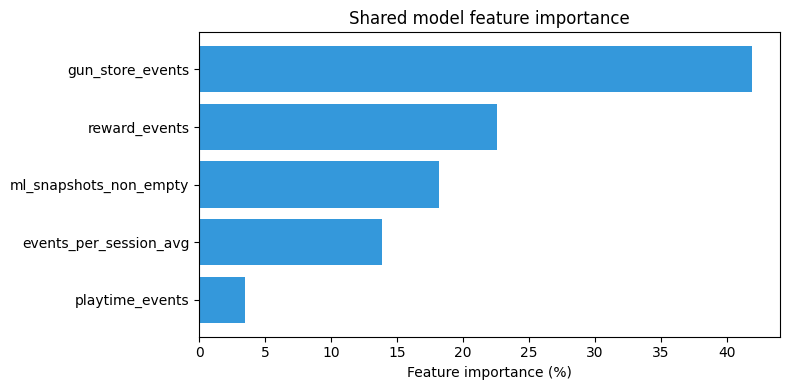

In [6]:
print("\n=== QUALITY REPORT ON NOTEBOOK SAMPLE ===")
print(f"Sample ROC-AUC score: {roc_auc_score(y_sample, probs):.4f}")
print("\nDetailed metrics:")
print(classification_report(y_sample, preds))

feature_importance = bundle.model.get_feature_importance()
importance_df = pd.DataFrame({'Feature': FEATURES, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='#3498db')
plt.title('Shared model feature importance')
plt.xlabel('Feature importance (%)')
plt.tight_layout()
plt.show()


### Обучим модель на одной группе, а проверим на контрольной выборке

In [7]:
# 5. Holdout-style check using the same shared modules
available_groups = sorted(df['data_group'].dropna().unique().tolist())
holdout_labels = ['cohort_alpha']

if not set(holdout_labels).issubset(set(available_groups)):
    raise ValueError(f'Unknown holdout labels: {holdout_labels}')

df_test_holdout = df[df['data_group'].isin(holdout_labels)].copy()
df_train_main = df[~df['data_group'].isin(holdout_labels)].copy()

print(f'Available groups: {available_groups}')
print(f'Training rows (main group): {len(df_train_main)}')
print(f'Test rows (holdout group): {len(df_test_holdout)}')


Available groups: ['cohort_alpha', 'cohort_beta']
Training rows (main group): 10282
Test rows (holdout group): 4405


In [8]:
X_holdout = df_test_holdout[FEATURES].fillna(0)
y_holdout = df_test_holdout['churn'].astype(int)

holdout_probs = predict_probabilities(bundle, X_holdout.to_dict(orient='records'))
holdout_preds = [int(prob >= bundle.decision_threshold) for prob in holdout_probs]

print("\n=== HOLDOUT EVALUATION REPORT ===")
print(f"ROC-AUC Score: {roc_auc_score(y_holdout, holdout_probs):.4f}")
print("\nDetailed metrics:")
print(classification_report(y_holdout, holdout_preds))

importance = bundle.model.get_feature_importance()
feat_importance = pd.DataFrame({'feature': FEATURES, 'importance': importance})
print("\nFeature importance:")
print(feat_importance.sort_values(by='importance', ascending=False))



=== HOLDOUT EVALUATION REPORT ===
ROC-AUC Score: 0.7736

Detailed metrics:
              precision    recall  f1-score   support

           0       0.85      0.67      0.75      3084
           1       0.48      0.72      0.58      1321

    accuracy                           0.69      4405
   macro avg       0.67      0.70      0.66      4405
weighted avg       0.74      0.69      0.70      4405


Feature importance:
                  feature  importance
1        gun_store_events   41.915560
2           reward_events   22.571796
3  ml_snapshots_non_empty   18.196809
0  events_per_session_avg   13.825183
4         playtime_events    3.490651
